In [1]:
import os
import sys
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath("code"))
from protein_from_RNA import *

In [2]:
random_seed = 0

In [3]:
# ==== Transcription rate ====
alpha_mu = 2 # (Corresponds to ~7 mRNAs/hour, per Chronocell paper)
alpha_sd = 1

# === Splicing rate ===
beta_mu = 2 # np.log(splicing_rate) # (Corresponds to ~8.5 minute splicing rate, per Chronocell paper)
beta_sd = 0.5

# === mRNA degradation rate ===
gamma_mu = 0.5 # (Corresponds to ~2.8 hour half-life, per Chronocell paper)
gamma_sd = 0.5

# === Translation rate === 
median_transl_rate = 30 # (per Jovanovic paper)
transl_rate_mu = np.log(median_transl_rate) # Median of lognormal
transl_rate_sd = 1

# === Protein degradation rate === 
median_protein_deg_rate = .01 # (per Jovanovic paper)
protein_deg_rate_mu = np.log(median_protein_deg_rate) # Median of lognormal
protein_deg_rate_sd = 1.5

In [4]:
# Simulate data

n = 1000 # No. cells per lineage
p = 200 # No. genes
topo = np.array([[0, 1, 2]])
tau = (0, 2, 6)

theta = get_RNA_params(topo, p, alpha_mu, alpha_sd, beta_mu, beta_sd, gamma_mu, gamma_sd, random_seed=random_seed)
phi = get_protein_params(p, transl_rate_mu, transl_rate_sd, protein_deg_rate_mu, protein_deg_rate_sd, random_seed=random_seed)
Y_observed, Y, theta, rd, true_t, true_l = simulate_RNA(topo, tau, theta, n, random_seed=random_seed)
P_observed, P = simulate_protein_from_RNA(Y_observed, topo, true_t, true_l, phi, random_seed=random_seed)

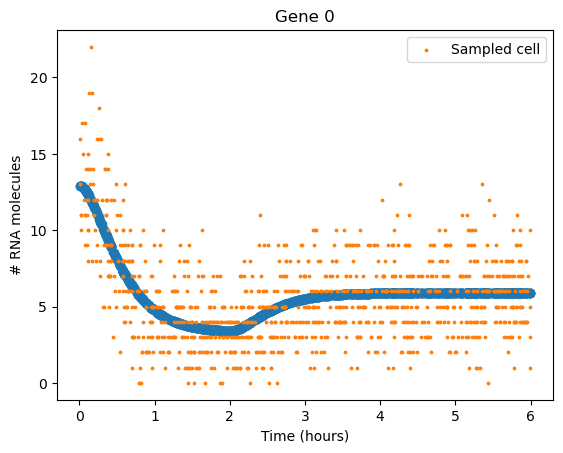

In [5]:
idx = 0

plt.scatter(true_t, Y[:, idx, 1]);
plt.scatter(true_t, Y_observed[:, idx, 1], s=3, label="Sampled cell");
plt.xlabel("Time (hours)");
plt.ylabel("# RNA molecules");
plt.title(f"Gene {idx}");
plt.legend();

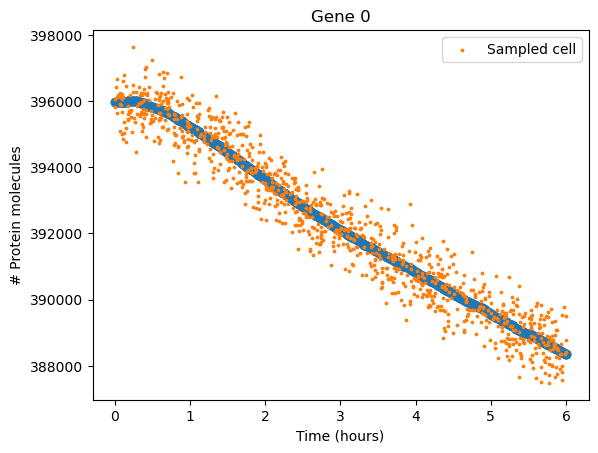

In [6]:
plt.scatter(true_t, P[:, idx]);
plt.scatter(true_t, P_observed[:, idx], s=3, label="Sampled cell");
plt.xlabel("Time (hours)");
plt.ylabel("# Protein molecules");
plt.title(f"Gene {idx}");
plt.legend();

# For a given gene:
## Calculate protein abundance from RNA levels using range of translation and protein degradation rates

In [48]:
# Now for each gene, sample a range of translation rates around true translation rate

n_resamples = 5
dispersion_factor = 1 # Smaller value = larger spread

In [ ]:
P_sampled_transl_observed, P_sampled_transl, sampled_transl_rates = simulate_protein_transl_rate_sensitivity(Y_observed, topo, true_t, true_l, phi, dispersion_factor, n_resamples, random_seed=random_seed)
P_sampled_deg_observed, P_sampled_deg, sampled_deg_rates = simulate_protein_deg_rate_sensitivity(Y_observed, topo, true_t, true_l, phi, dispersion_factor, n_resamples, random_seed=random_seed)

In [ ]:
sampled_transl_corrs = np.array([[np.corrcoef(P_sampled_transl_observed[r, :, idx], 
                                              P_observed[:, idx])[0, 1] for idx in range(p)] 
                                 for r in range(n_resamples)])

sampled_deg_corrs = np.array([[np.corrcoef(P_sampled_deg_observed[r, :, idx], 
                                           P_observed[:, idx])[0, 1] for idx in range(p)] 
                              for r in range(n_resamples)])

/mnt/lareaulab/reliscu/anaconda3/envs/chronocell/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/mnt/lareaulab/reliscu/anaconda3/envs/chronocell/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [11]:
sampled_transl_error = np.array([[np.sqrt((P_transl_sampled_observed[r, :, idx] - P_observed[:, idx])**2) for idx in range(p)] 
                                 for r in range(n_resamples)])
sampled_deg_error = np.array([[np.sqrt((P_deg_sampled_observed[r, :, idx] - P_observed[:, idx])**2) for idx in range(p)] 
                                 for r in range(n_resamples)])

In [12]:
gene_idx = 2

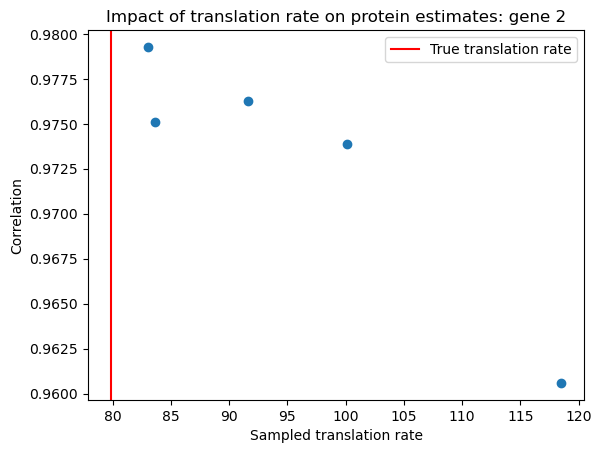

In [13]:
plt.scatter(sampled_transl_rates[gene_idx, :], sampled_transl_corrs[:, gene_idx]);
plt.axvline(x=phi[gene_idx, 0], color='red', label="True translation rate")
plt.xlabel("Sampled translation rate");
plt.ylabel("Correlation");
plt.title(f"Impact of translation rate on protein estimates: gene {gene_idx}");
plt.legend();

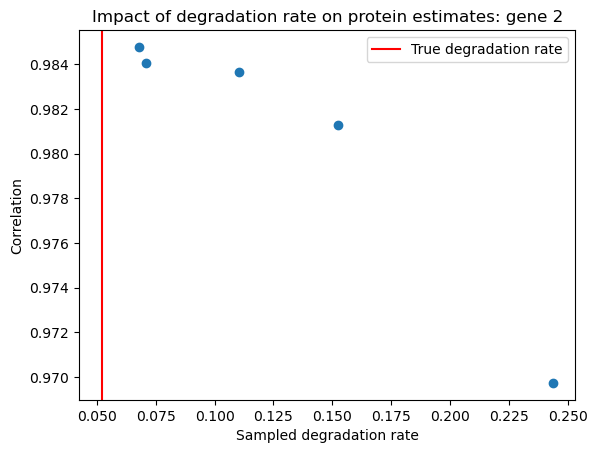

In [14]:
plt.scatter(sampled_deg_rates[gene_idx, :], sampled_deg_corrs[:, gene_idx]);
plt.axvline(x=phi[gene_idx, -1], color='red', label="True degradation rate")
plt.xlabel("Sampled degradation rate");
plt.ylabel("Correlation");
plt.title(f"Impact of degradation rate on protein estimates: gene {gene_idx}");
plt.legend();

In [ ]:
np.random.seed(random_seed)

L = len(topo) # No. lineages
n = Y.shape[0] // L # No. cells per lineage
p = Y.shape[1] # No. genes

y0 = Y[0, :, 1] # RNA levels at state 0
ss_rate = phi[:,0] / phi[:,-1] # Steady-state protein production rate = transl_rate/deg_rate
p0 = ss_rate * y0 # Initial protein abundance assuming steady-state

transl_rates = phi[:, 0].T

# "True" protein degradation rates per gene:
true_deg_rates = phi[:, -1, None]

# Sampled protein degradation rates per gene:
deg_rate_means = true_deg_rates
deg_rate_sds = np.sqrt(true_deg_rates / dispersion_factor)
sampled_deg_rates = np.random.normal(loc=deg_rate_means, scale=deg_rate_sds, size=(p, n_resamples))
# sampled_deg_rates = np.maximum(sampled_deg_rates, 0.0) # Degradation rates can't be negative 

In [19]:
sampled_deg_rates = np.random.normal(loc=deg_rate_means, scale=deg_rate_sds, size=(p, n_resamples))
sampled_deg_rates[gene_idx, :]

array([-0.00638406, -0.0362061 ,  0.07208489, -0.20354602, -0.09158857])

In [22]:
deg_rate_means

array([[5.74777220e-03],
       [6.98326328e-03],
       [5.20432179e-02],
       [2.67218261e-02],
       [2.61221178e-02],
       [8.84397220e-04],
       [9.64168520e-03],
       [3.30533797e-03],
       [1.52178943e-02],
       [8.63099254e-03],
       [3.91677402e-02],
       [1.60934509e-02],
       [3.25272122e-02],
       [4.96769747e-03],
       [2.42520416e-03],
       [5.40600598e-03],
       [9.74792530e-03],
       [1.76601855e-02],
       [2.96352172e-01],
       [9.38581367e-03],
       [2.38373263e-03],
       [5.95131634e-03],
       [4.98877870e-03],
       [2.05900367e-02],
       [9.91426535e-04],
       [1.09954119e-02],
       [1.26460498e-02],
       [1.41661689e-02],
       [4.08209766e-03],
       [6.99854660e-03],
       [1.18115613e-03],
       [4.77123541e-03],
       [4.42952732e-03],
       [1.86651876e-02],
       [1.76528376e-03],
       [3.22778826e-02],
       [9.40956586e-02],
       [4.48255254e-04],
       [1.89532077e-02],
       [2.76036261e-02],


In [ ]:
# For a given cell (Poisson sampled):
## Calculate its RNA history for each gene using: cell starting counts, and kinetic parameters (known) and recursive equation for expected # unspliced and spliced counts
